In [1]:
# 小型 Transformer 文字接龍專案 (莎士比亞全集版)
# 整理成 Google Colab 可直接執行版本，含進階功能：小型Attention視覺化

# =========================
# 1. 安裝套件
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import requests
import random
import math
import matplotlib.pyplot as plt

In [2]:

# =========================
# 2. 載入莎士比亞全集
# =========================
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text
print(f"總字數：{len(text)}")
print(text[:500])


總字數：1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# =========================
# 3. 數據處理
# =========================
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}

# 編碼與解碼函式
def encode(s):
    return [stoi[c] for c in s]

def decode(l):
    return ''.join([itos[i] for i in l])

# 整份文本轉成索引
data = torch.tensor(encode(text), dtype=torch.long)
train_data = data

In [4]:
# =========================
# 4. 建立小型 Transformer
# =========================
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=n_embd, nhead=n_head)
            for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)
        self.block_size = block_size

    def forward(self, idx):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x)
        return logits

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [5]:
# =========================
# 5. 訓練模型
# =========================
block_size = 64
batch_size = 32
n_embd = 128
n_head = 4
n_layer = 2
learning_rate = 3e-4
max_iters = 500

# 建立模型與優化器
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TransformerModel(vocab_size, n_embd, n_head, n_layer, block_size).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# 取得訓練批次資料
def get_batch():
    ix = torch.randint(len(train_data) - block_size, (batch_size,))
    x = torch.stack([train_data[i:i+block_size] for i in ix])
    y = torch.stack([train_data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# 訓練主程式
loss_list = []
for iter in range(max_iters):
    xb, yb = get_batch()
    logits = model(xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 50 == 0:
        print(f"Step {iter}, Loss: {loss.item():.4f}")
    loss_list.append(loss.item())


Step 0, Loss: 4.3733
Step 50, Loss: 2.8299
Step 100, Loss: 2.6734
Step 150, Loss: 2.5793
Step 200, Loss: 2.5444
Step 250, Loss: 2.5462
Step 300, Loss: 2.5200
Step 350, Loss: 2.4781
Step 400, Loss: 2.5335
Step 450, Loss: 2.5564


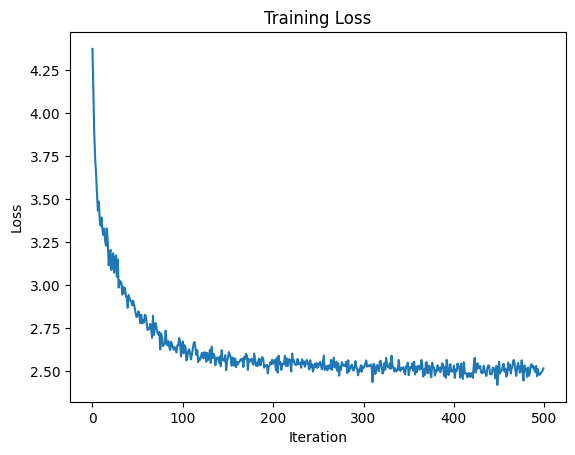

In [6]:
# =========================
# 6. 訓練損失圖示（進階）
# =========================
plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [9]:
# =========================
# 7. 使用者輸入文字並生成回覆
# =========================
# 使用者輸入初始文字
user_input = input("請輸入一句英文：")
input_ids = encode(user_input)
context = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)  # 增加 batch 維度

# 生成新的文字
generated_idx = model.generate(context, max_new_tokens=300)
response = decode(generated_idx[0].tolist())

print("\n生成的回覆：")
print(response)

請輸入一句英文：I think I'm afraid your path

生成的回覆：
I think I'm afraid your patheat m'do, mee In y owate n! r y thardoror t chaUSeag.
merdon f ing t Iy anderoredl wit b'T:
Bit o ldeaoftity fentit sthitnd ton thof s s ave, terdor sthan h walt s dende hu t w R:MK:

In.
TGTknest isusthe RAzto isted aEf stye, atee:
Toet onould?
T agives sorithang s, VI thof

ULet kid he ach pad

Y 
